## Сервис Яндекс Афиша


Автор: Луцкова Екатерина
Дата: 19.07.2026

## Цели и задачи проекта

<b>Цель проекта:</b> исследовать влияние фактора сезонности на активность пользователей; проверить две гипотезы относительно активности пользователей мобильных и стационарных устройств. 

<b>Задачи проекта:</b>

* загрузить данные и проверить их на корректность;
* провести исследовательский анализ данных;
* провести статистические тест для проверки гипотез;
* интепретировать результаты тестов.

## Описание данных

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 

Таблица имеет следующие поля:

* order_id — уникальный идентификатор заказа.
* user_id — уникальный идентификатор пользователя.
* created_dt_msk — дата создания заказа (московское время).
* created_ts_msk — дата и время создания заказа (московское время).
* event_id — идентификатор мероприятия из таблицы events.
* cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
* age_limit — возрастное ограничение мероприятия.
* currency_code — валюта оплаты, например rub для российских рублей.
* device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
* revenue — выручка от заказа.
* service_name — название билетного оператора.
* tickets_count — количество купленных билетов.
* total — общая сумма заказа.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события.

Датасет содержит такие поля:

* event_id — уникальный идентификатор мероприятия.
* event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
* event_type_description — описание типа мероприятия.
* event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
* organizers — организаторы мероприятия.
* region_name — название региона.
* city_name — название города.
* venue_id — уникальный идентификатор площадки.
* venue_name — название площадки.
* venue_address — адрес площадки.

Также в нашем распоряжении  датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. 

Датасет содержит такие поля:

* nominal — номинал (100 тенге).
* data — дата.
* curs — курс тенге к рублю.
* cdx — обозначение валюты (kzt).

## Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Исследовательский анализ данных
3. Статистический анализ данных
4. Выводы и рекомендации

# Загрузка данных и знакомство с ними

Загрузим данные по заказам и проверим, что выгрузка данных из SQL была успешной.

In [1]:
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy.stats import mannwhitneyu

In [2]:
df_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')

Проверим, что данные загрузились и выглядят корректно.

In [3]:
df_orders.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,Облачко,3,8206.70,19.0
6,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,201953,нет,16,rub,desktop,917.83,Край билетов,4,9178.26,NaN
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,Лучшие билеты,1,955.52,NaN
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,Лучшие билеты,2,2494.73,16.0
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,Лови билет!,4,17773.87,NaN


Теперь посмотрим на количество строк и типы данных в столбцах.

In [4]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Видим, что в датафрейме 14 столбцов и 290849 строк. Пропуски содержатся только в столбце `days_since_prev`, в остальных столбцах пропусков нет. 

Что касается типов данных, то в двух столбцах - `created_dt_msk` и `created_dt_msk` - задан неверно (object), необходимо будет привести данные к типу "datetime".
Столбец `days_since_prev` представлен типом данных float64, в то время как оптимальным для этих данных будет целочисленный тип, т.к. столбец хранит информацию о количестве дней.

Во всех остальных столбцах тип данных определен верно.

Теперь загрузим данные по событиям и проверим их на корректность.

In [5]:
df_events = pd.read_csv('/datasets/final_tickets_events_df.csv')

In [6]:
df_events.head(10)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"
5,8858,08008ffd-331c-4d77-8aad-c91691f87388,спектакль,театр,№896,Каменевский регион,Глиногорск,213,2148,"Лекции по искусству ""Хоровод"" и партнеры","пер. 50 лет Победы, д. 21 к. 90"
6,8863,2dc56536-e5ae-4d3a-9f00-f39c0ebe5b65,спектакль,театр,№3977,Медовская область,Радужсвет,47,2897,"Фестиваль уличного искусства ""Начало"" Инкорпор...","алл. Урицкого, д. 4/5 к. 1/3"
7,9041,1ab79186-41a8-420e-b618-dea51afd2c6f,спектакль,театр,№3582,Светополянский округ,Глиноград,54,3922,"Творческое агентство ""Симфония"" Лтд","бул. К.Маркса, д. 8/6"
8,9942,474ca8f8-3525-4ac0-9a98-4c1045e2fa6d,спектакль,театр,№1797,Широковская область,Радужнополье,35,3975,"Кабинет Искусств ""История"" и партнеры","пр. Гайдара, д. 4 к. 7/1"
9,9992,e36939d8-ef42-4f64-bd72-5a4199dd98f5,спектакль,театр,№1774,Тепляковская область,Горнодолинск,43,3959,"Эстетика ""Rhythm"" Инкорпорэйтед","ш. Вахитова, д. 7/8"


In [7]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датафрейм содержит 11 столбцов и 22427 строк. Видим, что пропущенные строки в датафрейме отсутствуют. Типы данных во всех столбцах определены корректно. 

<b>Объединение данных</b>

Для удобства дальнейшей работы объединим два датафрейма по общему полю `event_id` и создадим единый датафрейм - df_afisha. 

In [8]:
df_afisha = df_orders.merge(df_events, on = 'event_id')

Проверим, что объединение прошло успешно.

In [9]:
df_afisha.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
5,7431077,024dc5236465850,2024-07-23,2024-07-23 20:59:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
6,7431193,024dc5236465850,2024-07-23,2024-07-23 20:57:01,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
7,5635716,031d8c552e9438b,2024-07-21,2024-07-21 20:21:01,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
8,804403,07eb6c20b5518f4,2024-08-17,2024-08-17 16:24:29,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
9,4620339,0beb8fc0c0a9ce1,2024-07-25,2024-07-25 13:43:21,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


In [10]:
df_afisha.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

<b>Поиск пропусков</b>

Узнаем, каков процент пропусков в получившемся датафрейме, и решим, как поступить с ними дальше.

In [11]:
missing_share = df_afisha.isna().mean()
print(missing_share)

order_id                  0.000000
user_id                   0.000000
created_dt_msk            0.000000
created_ts_msk            0.000000
event_id                  0.000000
cinema_circuit            0.000000
age_limit                 0.000000
currency_code             0.000000
device_type_canonical     0.000000
revenue                   0.000000
service_name              0.000000
tickets_count             0.000000
total                     0.000000
days_since_prev           0.075403
event_name                0.000000
event_type_description    0.000000
event_type_main           0.000000
organizers                0.000000
region_name               0.000000
city_name                 0.000000
city_id                   0.000000
venue_id                  0.000000
venue_name                0.000000
venue_address             0.000000
dtype: float64


Доля пропусков составляет в столбце `days_since_prev` составляет 7,5%. Это некритичное значение, оно не окажет влияния на дальнейший анализ. Поэтому оставим пропуски без изменений. В остальных столбцах пропуски отсутствуют.

<b>Проверка категориальных значений</b>

Теперь изучим значения в ключевых столбцах. Начнем с категориальных значений - `cinema_circuit`, `age_limit`, `currency_code`, `event_type_description`, `event_type_main`. Также проверим регионы, типы устройств и билетных партнеров.

In [12]:
cinema_circuit_values = df_afisha['cinema_circuit'].value_counts()
age_values = df_afisha['age_limit'].value_counts()
currency_values = df_afisha['currency_code'].value_counts()
description_values = df_afisha['event_type_description'].value_counts()
event_type_main_values = df_afisha['event_type_main'].value_counts()
device_type_canonical_values = df_afisha['device_type_canonical'].value_counts()
region_name_values = df_afisha['region_name'].value_counts()
service_name_values = df_afisha['service_name'].value_counts()

print(f'Разнообразие значений в ключевых столбцах:')
print()
print('Сеть кинотеатров:\n',cinema_circuit_values)
print()
print('Возрастные категории:\n',age_values)
print()
print('Типы валют:\n',currency_values)
print()
print('Описание мероприятий:\n',description_values)
print()
print('Типы мероприятий:\n',event_type_main_values)
print()
print('Типы устройств:\n',device_type_canonical_values)
print()
print('Названия регионов:\n',region_name_values)
print()
print('Билетные партнеры:\n',service_name_values)



Разнообразие значений в ключевых столбцах:

Сеть кинотеатров:
 нет           289213
Другое          1261
КиноСити         122
Москино            7
Киномакс           7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

Возрастные категории:
 16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64

Типы валют:
 rub    285542
kzt      5069
Name: currency_code, dtype: int64

Описание мероприятий:
 концерт                   112049
событие                    58605
спектакль                  50592
шоу                        13626
спорт                      12837
мюзикл                      9919
спортивное мероприятие      9074
балет                       5998
выставка                    5876
цирковое шоу                5327
фестиваль                   4273
опера                       1314
ёлка                         945
музыкальный спектакль        140
кукольный спектакль           13
экскурсия                      8
оперетта                       7
п

Видим, что в столбце `cinema_circuit`, который хранит название сети кинотеатра, либо "нет", если кинотеатр несетевой, закралось значение "Другое". Скорее всего это значение-заглушка, которое ставили, если сеть кинотеатра определить не удалось, или по каким-то другим причинам. Также встречаются названия сетей (Киносити, Москино и др.).

Мы помним, что из датасета `final_tickets_events_df` исключили фильмы, поскольку событий такого типа не так много (судя по дашборду). Принимаем решение, что исключим строки о фильмах из объединенного датафрейма.

In [13]:
df_afisha = df_afisha[df_afisha['cinema_circuit'] == 'нет']

In [14]:
cinema_circuit_values = df_afisha['cinema_circuit'].value_counts()
print(cinema_circuit_values)

нет    289213
Name: cinema_circuit, dtype: int64


В `event_type_description` 58605 раз встречается категория "событие", это может обозначать отсутствие информации о типе мероприятия и является значением-заглушкой.

Категории "спорт" и "спортивное мероприятие" обознают одну и ту же сущность, поэтому "спортивное мероприятие" (встречается 9074 раза) заменим на более емкую категорию "спорт".

Кроме того, встречаются категории "музыкальный спектакль" (140 раз) и "кукольный спектакль" (13 раз). Далее заменим их на существующую категорию "спектакль". 

Значение "экскурсия" встречается 8 раз. Отнесем его к категории-индикатору "событие", поскольку другой подходящей категории для него нет.

Значение "оперетта" встречается 7 раз. Заменим его на наиболее подходящее значение "спектакль".

Значение "подарок", которое встречается 4 раза, отнесем к категории-индикатору "событие"

Значение "снегурочка" (встречается 3 раза) отнесем к категории "спектакль", а рок-мюзикл (1 раз) - к категории "мюзикл".

In [15]:
df_afisha['event_type_description'] = df_afisha['event_type_description'].replace({'спортивное мероприятие': 'спорт', 'музыкальный спектакль': 'спектакль', 'кукольный спектакль': 'спектакль', 'экскурсия': 'событие', 'оперетта': 'спектакль', 'подарок': 'событие', 'снегурочка': 'спектакль', 'рок-мюзикл': 'мюзикл'})

Проверим, что замена произведена успешно.

In [16]:
df_afisha['event_type_description'].value_counts()

концерт         111550
событие          58045
спектакль        50734
спорт            21909
шоу              13340
мюзикл            9911
балет             5998
выставка          5876
цирковое шоу      5327
фестиваль         4273
опера             1314
ёлка               936
Name: event_type_description, dtype: int64

Замена прошла успешно. В остальных категориальных столбцах не обнаружено каких-либо подозрительных или "выбивающихся" значений. 

<b>Проверка количественных значений</b>

Теперь посмотрим на количественные значения в ключевых столбцах - `revenue` и `tickets_count`. Поскольку данные изначально были представлены в разных валютах, разделим анализ на рубли и тенге.

In [17]:
df_afisha_rub = df_afisha[df_afisha['currency_code']=='rub']
df_afisha_kzt = df_afisha[df_afisha['currency_code']=='kzt']

<b>Заказы, оформленные в рублях</b>

Посмотрим на распределение значений и наличие выбросов в этих двух столбцах. 

In [18]:
print(f'Статистические показатели столбца revenue:')

df_afisha_rub['revenue'].describe()

Статистические показатели столбца revenue:


count    284144.000000
mean        547.372314
std         872.398103
min         -90.760000
25%         113.970000
50%         346.630000
75%         790.730000
max       81174.540000
Name: revenue, dtype: float64

Продемонстрируем распределение значений с помощью гистограммы и диаграммы размаха, убрав отображение выбросов (отфильтруем данные по 99-му процентилю).

In [19]:
p99 = df_afisha_rub['revenue'].quantile(0.99)
df_afisha_rub = df_afisha_rub[df_afisha_rub['revenue'] <= p99]

Text(0, 0.5, 'Частота')

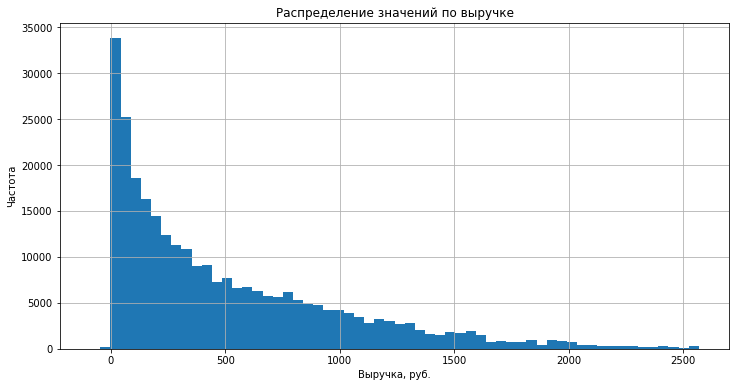

In [20]:
df_afisha_rub['revenue'].hist(bins=60, figsize = (12,6))

plt.title('Распределение значений по выручке')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')

Text(0.5, 0, 'Выручка, руб.')

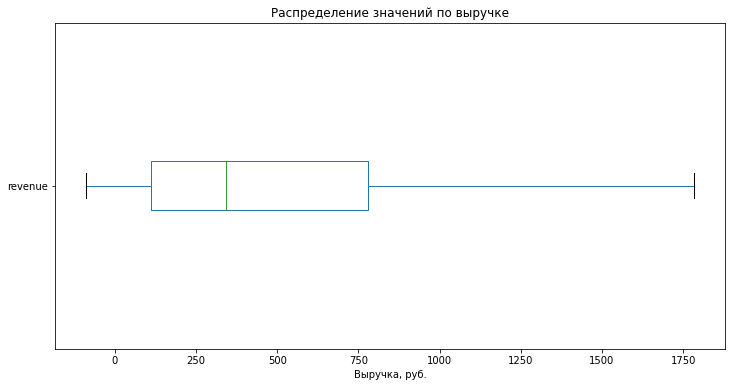

In [21]:
boxplot = df_afisha_rub.boxplot(column='revenue', vert=False, grid=False, showfliers=False, figsize=(12, 6))

plt.title('Распределение значений по выручке')
plt.xlabel('Выручка, руб.')

75% значений находится ниже отметки 790,7, с медианой в отметке около 300. При этом среднее значение - 547,3. Кроме того видим, что минимальное значение отрицательно (-90,7), а максимальное значение аномально большое (81174,5). 

На гистограмме наблюдается длинный "правый хвост", что свидетельствует о небольшой частоте встречаемости заказов с большой суммой.

Узнаем, сколько всего "отрицательных" заказов (возвратов) и заказов с 0-ой выручкой.

In [22]:
negative_values = df_afisha_rub[df_afisha_rub['revenue']<0]
negative_values

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
24218,1594653,00eb3dc9baa1543,2024-06-29,2024-06-29 15:01:43,538650,нет,0,rub,mobile,-2.37,...,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,событие,другое,№4651,Берёзовская область,Златопольск,74,4593,"Центр традиционных ремесел ""Путь"" Инк","алл. Чайковского, д. 6 к. 691"
24219,6620527,06727636bf2f465,2024-06-30,2024-06-30 05:40:34,538650,нет,0,rub,mobile,-1.58,...,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,событие,другое,№4651,Берёзовская область,Златопольск,74,4593,"Центр традиционных ремесел ""Путь"" Инк","алл. Чайковского, д. 6 к. 691"
24220,6444729,0beb8fc0c0a9ce1,2024-06-26,2024-06-26 03:22:06,538650,нет,0,rub,mobile,-1.58,...,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,событие,другое,№4651,Берёзовская область,Златопольск,74,4593,"Центр традиционных ремесел ""Путь"" Инк","алл. Чайковского, д. 6 к. 691"
24221,3015711,1783ebcbcdf41b1,2024-06-26,2024-06-26 06:11:20,538650,нет,0,rub,mobile,-2.37,...,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,событие,другое,№4651,Берёзовская область,Златопольск,74,4593,"Центр традиционных ремесел ""Путь"" Инк","алл. Чайковского, д. 6 к. 691"
24222,115537,1e3795ecb8bb655,2024-06-30,2024-06-30 07:15:20,538650,нет,0,rub,mobile,-1.58,...,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,событие,другое,№4651,Берёзовская область,Златопольск,74,4593,"Центр традиционных ремесел ""Путь"" Инк","алл. Чайковского, д. 6 к. 691"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289216,4829342,de70e44785b1efd,2024-09-13,2024-09-13 12:09:13,558354,нет,12,rub,mobile,-2.15,...,a5ccaa5b-c3ea-427f-8097-41697d6e8891,событие,другое,№1495,Серебряноярский округ,Лесозолотск,14,4674,"Народная школа искусств ""Сапфир"" Групп","пр. Комсомольский, д. 17 стр. 32"
290074,6411234,f3aee60b726d6fc,2024-08-20,2024-08-20 18:33:35,489425,нет,12,rub,mobile,-1.31,...,643d1190-5fc5-47e7-bc25-94f79ef8ec30,событие,другое,№3800,Светополянский округ,Родинсветск,20705,2842,"Народный театр ""Лагуна"" Групп","пр. Карьерный, д. 2/9 стр. 9"
290075,6411263,f3aee60b726d6fc,2024-08-20,2024-08-20 17:58:35,489425,нет,12,rub,mobile,-1.31,...,643d1190-5fc5-47e7-bc25-94f79ef8ec30,событие,другое,№3800,Светополянский округ,Родинсветск,20705,2842,"Народный театр ""Лагуна"" Групп","пр. Карьерный, д. 2/9 стр. 9"
290556,3700575,fe237d2cfd6e503,2024-10-12,2024-10-12 08:11:33,247058,нет,12,rub,mobile,-5.70,...,a3214473-934e-44ad-a8da-82915f51583f,концерт,концерты,№1437,Речицкая область,Радужанов,11,2136,"Театр документального кино ""Дизайнер"" Лтд","бул. 50 лет Победы, д. 881"


Обнаружен 381 заказ с отрицательной выручкой. 
Посмотрим, какова сумма возвратов по всем этим заказам, а также какой тип мероприятий чаще всего имеет отрицательную выручку.

In [23]:
negative_values_total = df_afisha_rub[df_afisha_rub['revenue']<0]['revenue'].sum()
print(negative_values_total)

-949.5899999999999


In [24]:
negative_values_type = df_afisha_rub[df_afisha_rub['revenue']<0]['event_type_main'].value_counts()
print(f'Типы мероприятий с отрицательной выручкой:\n{negative_values_type}')

Типы мероприятий с отрицательной выручкой:
другое      315
выставки     43
спорт        22
концерты      1
Name: event_type_main, dtype: int64


Итак, сумма "отрицательных" выручек составляет 950 руб. Это не такая большая сумма, поэтому она не должна повлиять на дальнейший анализ. 

Также мы выяснили, что чаще всего возвраты осуществляются в категориях "другое", "выставки" и "спорт".

Теперь посчитаем, сколько заказов с нулевой выручкой и что это за мероприятия.

In [25]:
zero_values = df_afisha_rub[df_afisha_rub['revenue']==0]
zero_values

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
1249,3253250,0018ecd8a38a51b,2024-07-25,2024-07-25 20:38:57,548041,нет,18,rub,mobile,0.0,...,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,спорт,№4548,Медовская область,Радужсвет,47,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
1250,5731329,02ea4583333f064,2024-07-12,2024-07-12 12:19:09,548041,нет,18,rub,mobile,0.0,...,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,спорт,№4548,Медовская область,Радужсвет,47,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
1251,3654813,0727e8d6b4f571e,2024-07-22,2024-07-22 22:09:38,548041,нет,18,rub,mobile,0.0,...,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,спорт,№4548,Медовская область,Радужсвет,47,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
1252,3654784,0727e8d6b4f571e,2024-07-23,2024-07-23 14:35:09,548041,нет,18,rub,mobile,0.0,...,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,спорт,№4548,Медовская область,Радужсвет,47,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
1253,5015638,1c2a2133e1df1b4,2024-07-29,2024-07-29 15:27:25,548041,нет,18,rub,desktop,0.0,...,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,спорт,№4548,Медовская область,Радужсвет,47,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290171,8188789,f6af1139a64d911,2024-10-31,2024-10-31 14:02:29,563139,нет,0,rub,mobile,0.0,...,5dbb69f1-9204-4329-a277-4f59e5d401f0,событие,другое,№2490,Лесостепной край,Крутовинск,44,4481,"Школа сценического мастерства ""Вдох"" Лтд","пер. Полярный, д. 87"
290172,8188209,f6af1139a64d911,2024-10-31,2024-10-31 11:58:26,563139,нет,0,rub,mobile,0.0,...,5dbb69f1-9204-4329-a277-4f59e5d401f0,событие,другое,№2490,Лесостепной край,Крутовинск,44,4481,"Школа сценического мастерства ""Вдох"" Лтд","пер. Полярный, д. 87"
290173,8188818,f6af1139a64d911,2024-10-31,2024-10-31 14:03:41,563139,нет,0,rub,mobile,0.0,...,5dbb69f1-9204-4329-a277-4f59e5d401f0,событие,другое,№2490,Лесостепной край,Крутовинск,44,4481,"Школа сценического мастерства ""Вдох"" Лтд","пер. Полярный, д. 87"
290214,5933169,f7a0146fc193947,2024-09-29,2024-09-29 12:55:01,494847,нет,6,rub,mobile,0.0,...,c721d0b9-a09d-4af7-9019-830de1a912bf,концерт,концерты,№3877,Зеленоградский округ,Шаныртау,24,3277,"Спектакль ""Атмосфера"" Лтд","бул. Вавилова, д. 7 к. 2"


In [26]:
zero_revenue_share = len(zero_values) / len(df_afisha_rub) *100
print(f'Доля заказов с нулевой выручкой: {zero_revenue_share}')

Доля заказов с нулевой выручкой: 1.9621573778183794


In [27]:
zero_values_type = df_afisha_rub[df_afisha_rub['revenue']==0]['event_type_main'].value_counts()
print(f'Типы мероприятий с нулевой выручкой:\n{zero_values_type}')

Типы мероприятий с нулевой выручкой:
другое      4128
концерты     796
спорт        325
театр        271
Name: event_type_main, dtype: int64


Всего нулевых заказов обнаружено 5520, это почти 2% от всех оформленных заказов. Чаще всего это заказы в категориях "другое", "концерты" и "спорт". 
Попробуем разобраться, почему так много заказов имеют нулевую выручку. Возможно в эти даты проводились какие-либо акции и сервис взимал только комиссию от партнеров. В то время, как пользователь ничего не платил за заказ. Посмотрим на столбец `total`. 

In [28]:
zero_values_total = df_afisha_rub[df_afisha_rub['revenue']==0]['total'].sum()
print(zero_values_total)

70840.17000000001


Видим, что несмотря на нулевую выручку, общая сумма заказов превышает 70 тысяч. Значит, версия с акцией для пользователей имеет место быть.

Посмотрим показатели по столбцу `tickets_count`.

In [29]:
print(f'Статистические показатели столбца tickets_count:')

df_afisha_rub['tickets_count'].describe()

Статистические показатели столбца tickets_count:


count    281323.000000
mean          2.739005
std           1.163637
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

Визуализируем данные на графиках.

Text(0, 0.5, 'Частота')

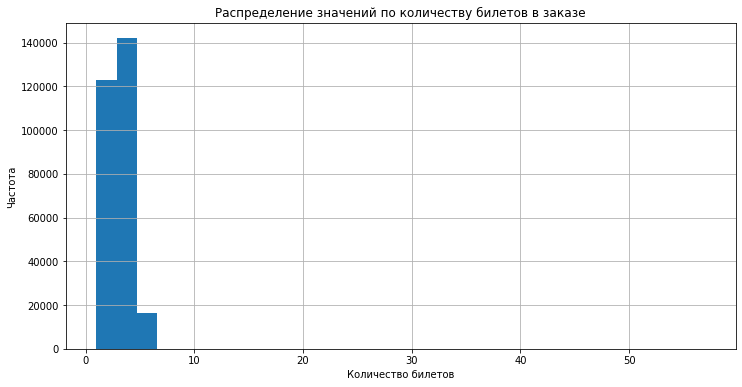

In [30]:
df_afisha_rub['tickets_count'].hist(bins=30, figsize = (12,6))

plt.title('Распределение значений по количеству билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')

Text(0.5, 0, 'Количество билетов')

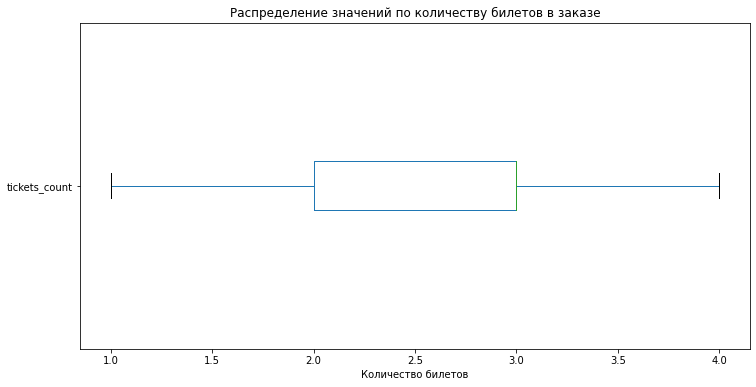

In [31]:
boxplot_2 = df_afisha_rub.boxplot(column='tickets_count', vert=False, grid=False, showfliers=False, figsize=(12, 6))

plt.title('Распределение значений по количеству билетов в заказе')
plt.xlabel('Количество билетов')

Таким образом, 75% пользователей покупали менее 4 билетов, среднее количество билетов в заказе - 3. Однако такой результат мог получится благодаря аномальному значению - 57 билетов в одном заказе. Данный тезис подтверждается на гистограмме - в основном распределение концентрируется от 1 до 7, при этом на шкале присутствует число 50.

<b>Заказы, оформленные в тенге</b>

Сейчас нам необходимо провести такой же анализ, только с заказами, оформленными в казахстанской валюте тенге.

Посмотрим на распределение значений в столбце `revenue` и наличие выбросов.

In [32]:
print(f'Статистические показатели столбца revenue:')

df_afisha_kzt['revenue'].describe()

Статистические показатели столбца revenue:


count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

Видим, что 75% значений лежит ниже отметки 7397,6, при среднем значении в 4995,2. Заказы с отрицательной выручкой отсутствуют, при этом есть заказы с нулевой выручкой. Максимальное значение 26425,8.

Построим гистограмму и диаграмму размаха для наглядности. 

Text(0, 0.5, 'Частота')

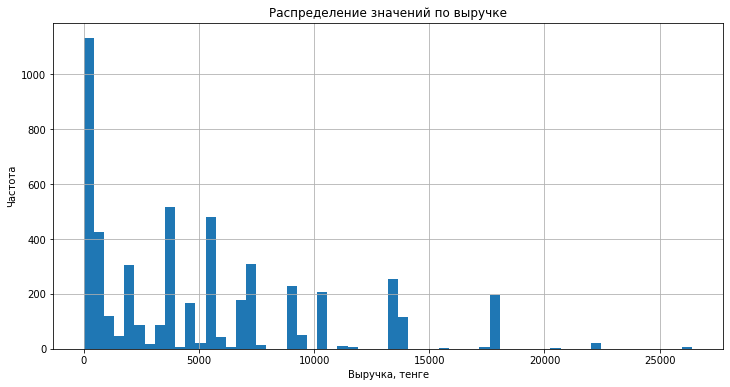

In [33]:
df_afisha_kzt['revenue'].hist(bins=60, figsize = (12,6))

plt.title('Распределение значений по выручке')
plt.xlabel('Выручка, тенге')
plt.ylabel('Частота')

Text(0.5, 0, 'Выручка, тенге.')

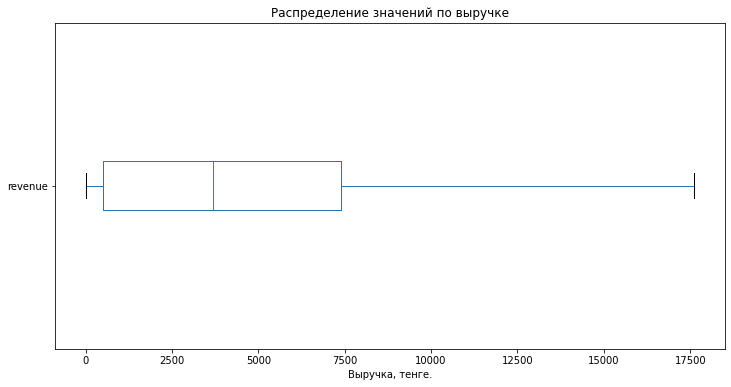

In [34]:
boxplot_3 = df_afisha_kzt.boxplot(column='revenue', vert=False, grid=False, showfliers=False, figsize=(12, 6))

plt.title('Распределение значений по выручке')
plt.xlabel('Выручка, тенге.')

В отличие от заказов, оформленных в рублях, заказы в тенге показывают большее разнообразие по части выручки. Гистограмма имеет асимметричный вид и представляет собой множество колонок разной высоты, это свидетельствует о большом разбросе значений. Как таковых больших выбросов или аномальных значений не наблюдается. Тем не менее можно говорить о наличии "правого хвоста" - уменьшении заказов с большой суммой. Диаграмма размаха подтверждает наши наблюдения.

Узнаем, сколько заказов с нулевой выручкой и что это за мероприятия.

In [35]:
zero_values_kzt = df_afisha_kzt[df_afisha_kzt['revenue']==0]
zero_values_kzt

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
288051,1121112,c7d4d0d8a2f0135,2024-08-26,2024-08-26 13:53:41,561940,нет,0,kzt,mobile,0.0,...,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,событие,другое,№4950,Шанырский регион,Синеводск,29463,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"
288052,1121170,c7d4d0d8a2f0135,2024-08-26,2024-08-26 13:54:30,561940,нет,0,kzt,mobile,0.0,...,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,событие,другое,№4950,Шанырский регион,Синеводск,29463,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"
288053,1121141,c7d4d0d8a2f0135,2024-08-26,2024-08-26 13:55:39,561940,нет,0,kzt,mobile,0.0,...,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,событие,другое,№4950,Шанырский регион,Синеводск,29463,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"
288054,1121199,c7d4d0d8a2f0135,2024-08-26,2024-08-26 13:52:40,561940,нет,0,kzt,mobile,0.0,...,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,событие,другое,№4950,Шанырский регион,Синеводск,29463,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"
288055,4693709,e75abeba6dd1fc4,2024-08-26,2024-08-26 13:57:39,561940,нет,0,kzt,mobile,0.0,...,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,событие,другое,№4950,Шанырский регион,Синеводск,29463,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"
288056,7537565,e75abeba6dd1fc4,2024-08-26,2024-08-26 14:51:26,561940,нет,0,kzt,desktop,0.0,...,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,событие,другое,№4950,Шанырский регион,Синеводск,29463,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"


In [36]:
zero_revenue_kzt_share = len(zero_values_kzt) / len(df_afisha_kzt) *100
print(f'Доля заказов с нулевой выручкой: {zero_revenue_kzt_share}')

Доля заказов с нулевой выручкой: 0.11836654172420596


Всего 6 заказов (0,11%) имеют нулевую выручку. На анализ это не окажет значительного влияния.
Все заказы относятся к одному и тому же мероприятию - "event_id 561940". Скорее всего, что 6 билетов были реализованы в рамках акции (промокод на 100% скидку, подарок и т.д.)

Теперь посмотрим показатели по столбцу `tickets_count`.

In [37]:
print(f'Статистические показатели столбца tickets_count:')
df_afisha_kzt['tickets_count'].describe()

Статистические показатели столбца tickets_count:


count    5069.000000
mean        2.762872
std         1.115558
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64

Покажем распределение на графиках.

Text(0, 0.5, 'Частота')

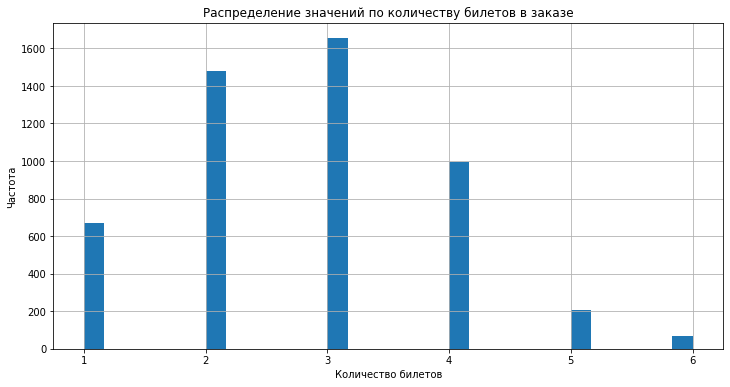

In [38]:
df_afisha_kzt['tickets_count'].hist(bins=30, figsize = (12,6))

plt.title('Распределение значений по количеству билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')

Text(0.5, 0, 'Количество билетов')

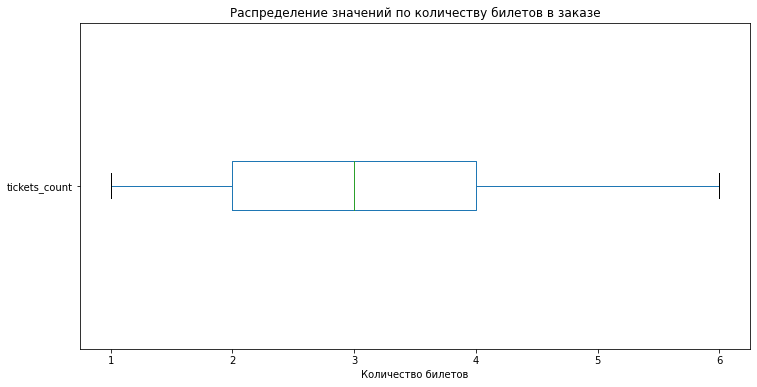

In [39]:
boxplot_4 = df_afisha_kzt.boxplot(column='tickets_count', vert=False, grid=False, showfliers=False, figsize=(12, 6))

plt.title('Распределение значений по количеству билетов в заказе')
plt.xlabel('Количество билетов')

В отличие от заказов за рубли, распределение значений в казахстанской валюте нормальное, аномальные значения отсутствуют. 

----------------------------------------------------

Напомним, что в заказах за российскую валюту мы обнаружили выбросы, которые могут исказить картину. Для дальнейшей работы мы будем использовать отобранные по 99-му процентилю данные в столбце `revenue`, тем самым исключим эти выбросы.

In [40]:
df_afisha = df_afisha[(df_afisha['currency_code']=='rub')&(df_afisha['revenue'] <= p99)]

<b>Поиск дубликатов</b>

Проверим данные на наличие дубликатов. Начнем с поиска явных дубликатов.

In [41]:
df_afisha.duplicated().sum()

0

Видим, что явные дубликаты отсутствуют.
Проверим, имеются ли неявные дубликаты (полное совпадение всех полей, кроме поля `order_id`).

In [42]:
df_afisha[df_afisha.duplicated(subset=[c for c in df_afisha.columns if c != 'order_id'], keep=False)]

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
3838,7299649,a0384c26d91e09e,2024-08-24,2024-08-24 00:07:14,534657,нет,16,rub,mobile,679.21,...,dff567b7-11a5-4c4c-b223-70c8ab7efd15,концерт,концерты,№1134,Ветренский регион,Кокжар,20,2866,"Школа фотографии ""Золотое"" Инк","ш. Микрорайон, д. 79 стр. 50"
3839,7299678,a0384c26d91e09e,2024-08-24,2024-08-24 00:07:14,534657,нет,16,rub,mobile,679.21,...,dff567b7-11a5-4c4c-b223-70c8ab7efd15,концерт,концерты,№1134,Ветренский регион,Кокжар,20,2866,"Школа фотографии ""Золотое"" Инк","ш. Микрорайон, д. 79 стр. 50"
8912,1585808,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
8915,7927528,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
48970,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"
48973,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"
48977,5373179,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"
79429,312621,8d6c1ff89fac35f,2024-10-31,2024-10-31 22:28:57,589624,нет,16,rub,desktop,41.83,...,c9eb1fa4-257b-4290-975a-7fe34b46d11b,концерт,концерты,№2121,Каменевский регион,Глиногорск,213,1365,"Картинная галерея ""Светлячок"" Лтд","ул. Дальневосточная, д. 97 к. 1/4"
79485,6114564,8d6c1ff89fac35f,2024-10-31,2024-10-31 22:28:57,589624,нет,16,rub,desktop,41.83,...,c9eb1fa4-257b-4290-975a-7fe34b46d11b,концерт,концерты,№2121,Каменевский регион,Глиногорск,213,1365,"Картинная галерея ""Светлячок"" Лтд","ул. Дальневосточная, д. 97 к. 1/4"
101421,2321712,cbe06d8837e87fb,2024-10-01,2024-10-01 11:20:05,574431,нет,0,rub,desktop,155.99,...,d4344522-b7cf-4539-96c8-efece75e9b16,спорт,спорт,№1531,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"


Обнаружилось 58 строк (или 29 пар заказов) с полным совпадением всех полей (кроме номера заказа). Такие строки относятся к неявным дубликатам. Для корректной  проверки гипотез каждый заказ должен встречаться не более 1 раза. Поэтому нам необходимо избавиться от неявных дублей и оставить по одному заказу из каждой пары.

In [43]:
cols_to_check = [c for c in df_afisha.columns if c != 'order_id']
df_afisha = df_afisha.drop_duplicates(subset=cols_to_check, keep='first')

Проверим, что дубликаты удалились.

In [44]:
df_afisha[df_afisha.duplicated(subset=[c for c in df_afisha.columns if c != 'order_id'], keep=False)]

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address


Теперь проверим данные на другие виды неявных дубликатов.
Один из них - разный `order_id`, но одинаковое содержание других столбцов (неявные дубли по смыслу).

In [45]:
cols_to_check_2 = ['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'revenue', 'tickets_count', 'total']
duplicates_columns = (df_afisha.duplicated(subset=cols_to_check_2, keep=False))

df_duplicates = df_afisha[duplicates_columns].sort_values(cols_to_check_2)
print(f'Строк с неявными дублями по содержанию: {len(df_duplicates)}')

Строк с неявными дублями по содержанию: 24


Выявлено 24 строки с дублирующимися значениями в ключевых колонках, но при этом с разным id заказа.
Посмотрим на эти заказы, чтобы понять, что с ними делать дальше.

In [46]:
df_duplicates

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
151803,5593202,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,mobile,0.00,...,8aa79719-8122-4b50-ae2a-fa484d034c5c,событие,другое,№4549,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
151804,5592970,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,desktop,0.00,...,8aa79719-8122-4b50-ae2a-fa484d034c5c,событие,другое,№4549,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
126876,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
126878,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
100394,5378312,1f49b8de206b285,2024-10-01,2024-10-01 11:32:40,574431,нет,0,rub,desktop,155.99,...,d4344522-b7cf-4539-96c8-efece75e9b16,спорт,спорт,№1531,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"
100425,2968673,1f49b8de206b285,2024-10-01,2024-10-01 11:32:40,574431,нет,0,rub,mobile,155.99,...,d4344522-b7cf-4539-96c8-efece75e9b16,спорт,спорт,№1531,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"
43477,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213,4363,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
43479,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213,4363,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
261913,3326185,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,...,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43,3873,"Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"
261914,3326272,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,...,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43,3873,"Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"


Видим, что 24 заказа (12 пар) совпадают вплоть до секунды, когда он был оформлен. Делаем вывод, что произошла техническая ошибка и заказы задублировались попарно. Можем смело удалить дубли, оставив по одному заказу из каждой пары.

In [47]:
df_afisha = df_afisha.drop_duplicates(subset=cols_to_check_2, keep='first')

Проверим, что дубликаты удалились.

In [48]:
cols_to_check_2 = ['user_id', 'created_ts_msk', 'event_id', 'revenue', 'tickets_count', 'total']

still_duplicates = df_afisha.duplicated(subset=cols_to_check_2, keep=False).sum()
print(f'Осталось дублей: {still_duplicates}')

Осталось дублей: 0


Проверим еще один случай дублирования - одинаковый `order_id`, но разное содержание (дубли по ключу).

In [49]:
df_afisha['order_id'].duplicated().sum()

0

Дубли по ключу отсутствуют. Таким образом, дубликатов (явных и неявных) больше нет.

<b>Преобразование типов данных</b>

Приведем значения в столбцах `created_dt_msk` и `created_ts_msk` к типу datetime, а значения в столбце `days_since_prev` - к типу int, как мы и планировали в начале.

In [50]:
df_afisha['created_dt_msk'] = df_afisha['created_dt_msk'].astype('datetime64[ns]')

In [51]:
df_afisha['created_ts_msk'] = df_afisha['created_ts_msk'].astype('datetime64[ns]')

In [52]:
df_afisha['days_since_prev'] = df_afisha['days_since_prev'].astype('Int64')

<b>Приведение выручки с заказа к единой валюте</b>

Используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю `final_tickets_tenge_df.csv` за 2024 год. 
Загрузим данные из датасета и проверим их на корректность.

In [53]:
df_curs = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [54]:
df_curs.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [55]:
df_curs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


В датафрейме 357 строк, пропуски отсутствуют. Столбец `data` хранит информацию о дате, однако ошибочно представлен типом данных object. Приведем его к подходящему типу данных, а также переименуем столбец для удобства слияния.

In [56]:
df_curs['data'] = df_curs['data'].astype('datetime64[ns]')

In [57]:
df_curs = df_curs.rename(columns={'data': 'created_dt_msk'})

Проверим данные на предмет дубликатов.

In [58]:
df_curs.duplicated().sum()

0

Дубликатов не обнаружено. 

Теперь посмотрим на разнообразие значений в столбцах `nominal`, `curs`и `cdx`, чтобы убедиться, что они хранят только релевантные значения. 

In [59]:
df_curs['nominal'].value_counts()

100    357
Name: nominal, dtype: int64

In [60]:
df_curs['curs'].value_counts()

20.7013    5
20.8961    5
20.2783    4
20.5750    4
20.1634    3
          ..
19.7930    1
19.0699    1
18.9444    1
19.5798    1
20.3751    1
Name: curs, Length: 248, dtype: int64

In [61]:
df_curs['cdx'].value_counts()

kzt    357
Name: cdx, dtype: int64

Мы убедились, что посторонних значений в датасете нет. 

Поскольку в дальнейшем мы будем присоединять таблицы по ключу "дата", необходимо проверить этот столбец на отсутствие дубликатов.

In [62]:
df_curs['created_dt_msk'].duplicated().sum()

0

В столбце с ключом дубликатов нет.

Поскольку в датасете был дан курс за 100 тенге, нам нужно узнать курс за 1 тенге. Создадим дополнительное поле `curs_per_tenge`.

In [63]:
df_curs['curs_per_tenge'] = df_curs['curs'] / 100

Присоединим вновь созданный датафрейм к имеющемуся датафрейму `df_afisha` по дате.

In [64]:
df = df_afisha.merge(df_curs, on = 'created_dt_msk', how = 'left')

Проверим, что слияние прошло успешно.

In [65]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,nominal,curs,cdx,curs_per_tenge
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.6972,kzt,0.186972
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.3419,kzt,0.183419
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.3419,kzt,0.183419
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.3419,kzt,0.183419
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.3419,kzt,0.183419


Приведем выручку с заказа к российскому рублю и создадим столбец `revenue_rub`.

In [66]:
currency_col = 'currency_code'

def convert_to_rub(row):
    if row[currency_col] == 'rub':
        return row['revenue']            
    elif row[currency_col] == 'kzt':
        return row['revenue'] * row['curs_per_tenge']

df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

<b>Расчет выручки с продажи одного билета</b>

Рассчитаем выручку с продажи одного билета на мероприятие. Для этого создадим дополнительный столбец `one_ticket_revenue_rub`.

In [67]:
df['one_ticket_revenue_rub'] = (df['revenue_rub'] / df['tickets_count']).round(2)

<b>Информация о сезонности</b>

Выделим месяц оформления заказа в отдельный столбец - `month`.

In [68]:
df['month'] =  df['created_dt_msk'].dt.month

Создадим столбец `season` с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [69]:
month_number = 'month'

def write_season(row):
    if 6 <= row[month_number] <=8:
        return 'лето'
    elif 9 <= row[month_number] <=11:
        return 'осень' 

df['season'] = df.apply(write_season, axis=1)

<b>Промежуточные выводы</b>

В этом разделе мы познакомились с имеющимися данными и провели их предобработку: 
* привели столбцы к подходящим типам данных, 
* избавились от заказов-дубликатов, которые помешали бы корректному проведению А/В-тестирования и проверке гипотез,
* проверили данные на предмет пропусков.

Кроме того, мы изучили распределение данных в ключевых столбцах - категориальных и количественных. Были обнаружены аномальные значения в столбце `revenue` (это были заказы, оформленные в рублях). Для дальнейшей работы мы исключили эти аномальные значения, предупреждая тем самым искажение анализа.

В заключении мы создали несколько дополнительных столбцов, которые пригодятся нам при анализе поведения и активности пользователей:
* `revenue_rub` — с указанием выручки с заказа в единой валюте,
* `one_ticket_revenue_rub`, который хранит выручку с продажи одного билета на мероприятие,
* `month` — с месяцем оформления заказа,
* `season` —  с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

# Исследовательский анализ данных

<b>Анализ распределения заказов по сегментам и их сезонные изменения</b>

Изучим изменение пользовательской активности или пользовательского интереса в связи с сезонностью. Проанализируем динамику по таким разрезам:
* тип мероприятия event_type_main;
* тип устройства device_type_canonical;
* категория мероприятий по возрастному рейтингу age_limit.

Начнем с того, что для каждого месяца найдем количество заказов и визуализируем результаты.

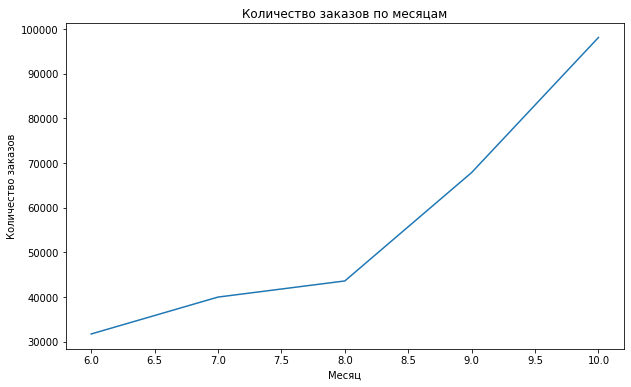

In [70]:
orders_per_month = df.groupby('month')['order_id'].count()

orders_per_month.plot(kind = 'line',
                      title ='Количество заказов по месяцам',
                      rot = 0, 
                      ylabel = 'Количество заказов', 
                      xlabel = 'Месяц',
                      figsize=(10, 6))
plt.show()

На графике видно, что, начиная со второй половины августа, наблюдается резкий скачок количества заказов. Положительная динамика продолжается вплоть до конца октября. 

Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу.

Сперва узнаем, как изменились предпочтения пользователей по части мероприятий. 

Для этого вычислим, как распределились доли мероприятий внутри осеннего и летнего сезонов и далее сравним эти показатели.

In [71]:
df_grouped_events = (df[df['season'].isin(['лето', 'осень'])].groupby(['event_type_main', 'season'])['order_id'].count().unstack(fill_value=0))
df_grouped_events

season,лето,осень
event_type_main,,
выставки,2315,2285
другое,31745,31979
концерты,47814,61975
спорт,2967,18611
стендап,6264,6729
театр,23923,42718
ёлки,273,1683


In [72]:
events_shares = (df_grouped_events / df_grouped_events.sum()) * 100
events_shares = events_shares.round(2)
print(f'Изменение долей заказов по типам мероприятий внутри сезонов, %:\n{events_shares}')

Изменение долей заказов по типам мероприятий внутри сезонов, %:
season            лето  осень
event_type_main              
выставки          2.01   1.38
другое           27.53  19.27
концерты         41.47  37.34
спорт             2.57  11.21
стендап           5.43   4.05
театр            20.75  25.74
ёлки              0.24   1.01


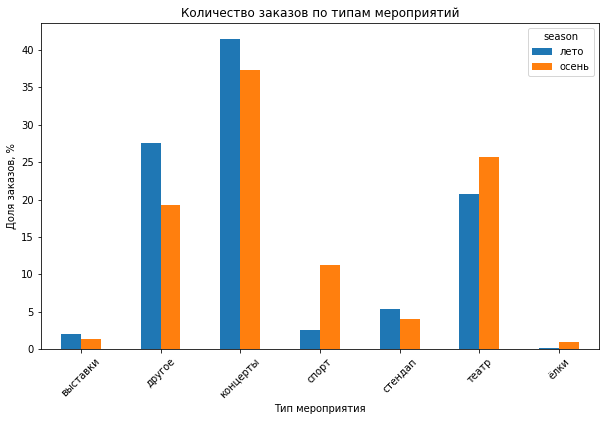

In [73]:
events_shares.plot(kind='bar',
                title='Количество заказов по типам мероприятий',
                xlabel='Тип мероприятия',
                ylabel='Доля заказов, %',
                rot=45,
                figsize=(10, 6))

plt.show()

Видим, что осенью пользователи стали чаще покупать билеты на три типа мероприятий: "спорт" (11.21% против 2.57% в летний период), "театр" (25.74% против 20.75% летом), тип "ёлки" показал небольшой рост - 1,01% против 0.24%. 8% по сравнению с летом потеряла категория "другое".
Доля заказов в остальных типах мероприятий осенью не показала значительных сдвигов. К ним интерес публики не возрос в сравнении с летним сезоном. 

Оценим, как изменилось количество заказов по типу устройств.

In [74]:
df_grouped_device = (df[df['season'].isin(['лето', 'осень'])].groupby(['device_type_canonical', 'season'])['order_id'].count().unstack(fill_value=0))
df_grouped_device

season,лето,осень
device_type_canonical,,
desktop,21897,33808
mobile,93404,132172


In [75]:
device_shares = (df_grouped_device / df_grouped_device.sum()) * 100
device_shares = device_shares.round(2)
print(f'Изменение долей заказов по типам устройств внутри сезонов, %:\n{device_shares}')

Изменение долей заказов по типам устройств внутри сезонов, %:
season                  лето  осень
device_type_canonical              
desktop                18.99  20.37
mobile                 81.01  79.63


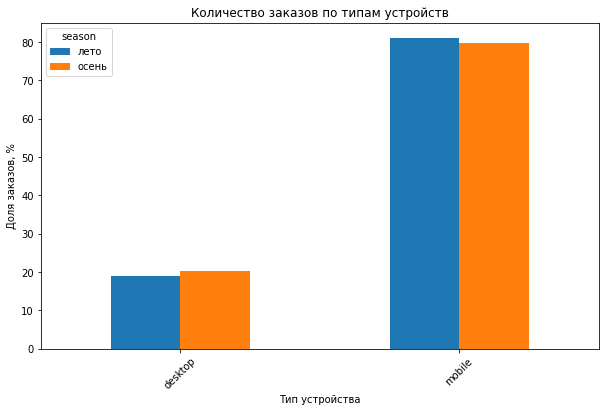

In [76]:
device_shares.plot(kind='bar',
                title='Количество заказов по типам устройств',
                xlabel='Тип устройства',
                ylabel='Доля заказов, %',
                rot=45,
                figsize=(10, 6))

plt.show()

Видим, что в осенний сезон пользователи не изменили своим привычкам и по-прежнему предпочитают мобильную версию. Однако, стационарная платформа прибавила почти 2% по сравнению с летом.

Теперь покажем, как осенью изменилась доля заказов в зависимости от возрастного рейтинга мероприятия.

In [77]:
df_grouped_age = (df[df['season'].isin(['лето', 'осень'])].groupby(['age_limit', 'season'])['order_id'].count().unstack(fill_value=0))
df_grouped_age

season,лето,осень
age_limit,,
0,21128,39237
6,21385,28668
12,22958,36846
16,32113,43829
18,17717,17400


In [78]:
age_shares = (df_grouped_age / df_grouped_age.sum()) * 100
age_shares = age_shares.round(2)
print(f'Изменение долей заказов по возрастной категории внутри сезонов, %:\n{age_shares}')

Изменение долей заказов по возрастной категории внутри сезонов, %:
season      лето  осень
age_limit              
0          18.32  23.64
6          18.55  17.27
12         19.91  22.20
16         27.85  26.41
18         15.37  10.48


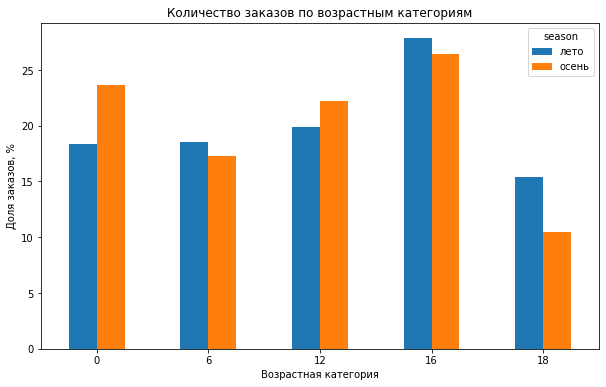

In [79]:
age_shares.plot(kind='bar',
                title='Количество заказов по возрастным категориям',
                xlabel='Возрастная категория',
                ylabel='Доля заказов, %',
                rot=0,
                figsize=(10, 6))

plt.show()

Заметим, что осенью у пользователей возрос интерес к мероприятиям категории "0" и "12" (+5.32% и +2.29% по сравнению с летом соответственно). А вот категория "18" напротив потеряла 5%.
В остальных категориях предпочтения потребителей критично не изменились (плюс-минус 1-1,5 процентных пункта, которые компенсируют друг друга).

Изучим изменение выручки с продажи одного билета в зависимости от сезонности. 

Для каждого типа мероприятия рассчитаем среднее значение выручки с одного билета (в абсолютном выражении) и визуализируем результат на графике.

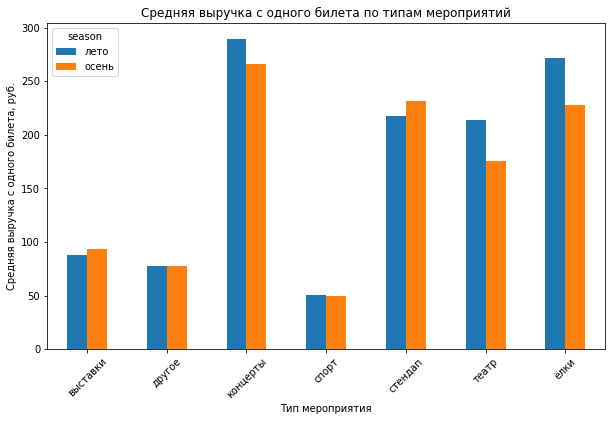

In [80]:
df_grouped_event_avg = df.groupby(['event_type_main','season'])['one_ticket_revenue_rub'].mean().unstack(fill_value=0)

df_grouped_event_avg.plot(kind='bar',
                title='Средняя выручка с одного билета по типам мероприятий',
                xlabel='Тип мероприятия',
                ylabel='Средняя выручка с одного билета, руб.',
                rot=45,
                figsize=(10, 6))

plt.show()

Теперь посчитаем ту же величину, но уже в относительном выражении.
Для этого отдельно сохраним разницу в переменную `revenue_change`. 

In [81]:
revenue_change = ((df_grouped_event_avg['осень'] - df_grouped_event_avg['лето']) / df_grouped_event_avg['лето'] * 100).round(1)
print(f'Изменение средней выручки с одного билета (осень vs лето), %:\n{revenue_change}')

Изменение средней выручки с одного билета (осень vs лето), %:
event_type_main
выставки     6.0
другое       0.2
концерты    -8.0
спорт       -1.3
стендап      6.0
театр      -17.9
ёлки       -15.9
dtype: float64


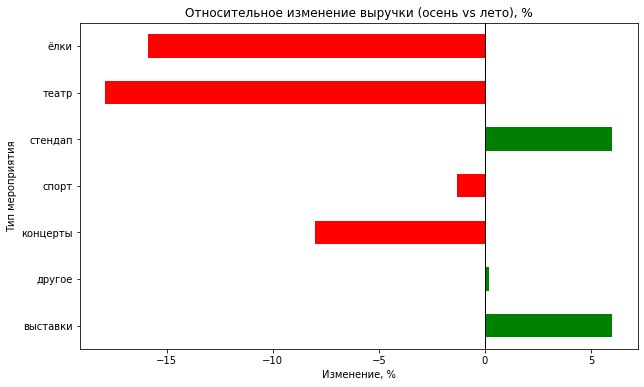

In [82]:
colors = ['green' if x >= 0 else 'red' for x in revenue_change.values]

revenue_change.plot(
    kind='barh',
    figsize=(10, 6),
    color = colors,
    title='Относительное изменение выручки (осень vs лето), %'
)
plt.axvline(0, color='black', linewidth=1)  # линия 0%
plt.xlabel('Изменение, %')
plt.ylabel('Тип мероприятия')

plt.show()

Оба графика наглядно демонстрируют, что осенью средняя выручка с одного билета выросла только в трех типах мероприятий - "выставки" (+6%), "стендап" (+6%) и "другое" (+0,2%).
По остальным категориям мероприятий средняя выручка с одного билета показывает отрицательную динамику. Так, например, в категории "театр" этот показатель упал почти на 18%. На втором месте в антирейтинге категория "ёлки" (-15,9%), на третьем - "концерты" (-8%).

<b>Промежуточный вывод</b>

На этом этапе мы оценили, как распределяется количество заказов в зависимости от сезонности (лето и осень). Провели анализ в разрезе нескольких категорий: тип мероприятия, тип устройства, возрастное ограничение.

Осенью пользователи стали чаще покупать билеты на три типа мероприятий: "спорт", "театр" и "ёлки". Причины этого явления сводятся к простой закономерности: спортивный и театральный сезоны обычно начинаются в конце лета или начале осени, совпадая с началом учебного года и возвращением людей из отпусков.
Приближение новогодних ивентов объясняет повышение интереса к типу мероприятия "ёлки". 

В осенний сезон пользователи по-прежнему предпочитают мобильную версию. Однако стационарная платформа прибавила почти 2% по сравнению с летом. Напрашивается вывод о неизменности привычек пользователей и удобстве мобильной версии. 

У пользователей возрос интерес к мероприятиям категории "0" и "12". Скорее всего это мероприятия, ориентированные на детей и подростков. Тенденция вполне объяснимая с учетом окончания летних каникул и возвращения детей с отдыха. 

Вопреки ожиданиям, осенью средняя выручка с одного билета выросла только в трех типах мероприятий. По остальным категориям мероприятий средняя выручка с одного билета показывает отрицательную динамику. Стоит присмотреться к этим категориям и выяснить причины столь значительного падения средней выручки при абсолютном росте количества заказов. 

Отметим, что в нашем распоряжении имеется информация лишь о небольшом временном промежутке. Для формулирования более точных и достоверных выводов и гипотез нужно убедиться в том, что тенденции повторяются из года в год. 


<b>Осенняя активность пользователей</b>

Изучим активность пользователей осенью 2024 года. 

Вначале проанализируем динамику изменений по дням для общего числа заказов и количества активных пользователей (DAU). Для этого создадим таблицу, и в ней по дням рассчитаем число заказов и число уникальных пользователей.

In [83]:
df_fall = df[df['season']=='осень']

In [84]:
daily_stats = df_fall.groupby('created_dt_msk').agg(orders_count=('order_id', 'count'), dau=('user_id', 'nunique')).reset_index()
daily_stats

,created_dt_msk,orders_count,dau
0,2024-09-01,1303,553
1,2024-09-02,1330,549
2,2024-09-03,5020,728
3,2024-09-04,1658,626
4,2024-09-05,1837,692
...,...,...,...
56,2024-10-27,2812,1022
57,2024-10-28,2775,959
58,2024-10-29,2760,966
59,2024-10-30,2868,1017


Визуализируем результаты с помощью линейного графика.

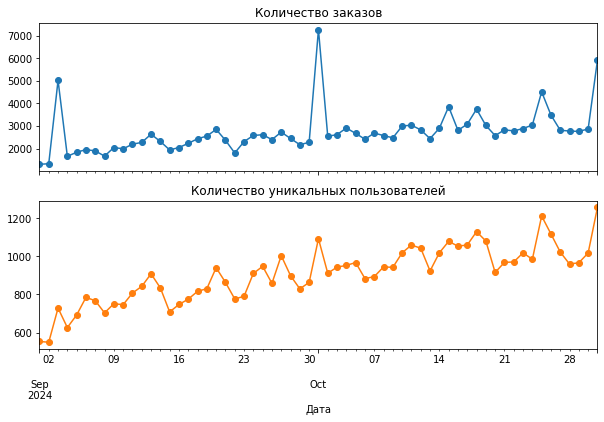

In [85]:
daily_stats_agg = df_fall.groupby('created_dt_msk').agg({'order_id': 'count', 'user_id': 'nunique'})

daily_stats_agg.plot(kind='line',
                 subplots=True,
                 sharex=True,
                 sharey=False,
                 legend=False,
                 figsize=(10, 6),
                 marker='o',
                 title=['Количество заказов', 'Количество уникальных пользователей'])

plt.xlabel('Дата')
plt.show()

На графике видно, что количество заказов в сентябре и октябре характеризуется умеренной стабильностью. Так, фиксируется несколько пиковых значений: 3 сентября, 1 и 31 октября, после которых следует резкий спад. Кроме того, имеются небольшие "точки роста" 15, 18 и 25 октября. 
В целом можно говорить о небольшой положительной динамике, несмотря на то, что по всей кривой значение не превышало 3000 заказов в день, за исключением тех дат, которые мы перечислили выше.

Что касается показателя DAU, то здесь можно говорить о положительной динамике, начиная со 2 сентября, когда число пользователей превысило 700 человек, в дальнейшем до конца исследуемого периода DAU не опускалось ниже отметки 600. Пиковые значения были зафиксированы 1, 19, 25 и 31 октября, что совпадает с наибольшим числом оформленных заказов.

Кривые на обоих графиках визуально похожи. Это говорит о том, что данные коррелируются между собой. Вероятно, в "пиковые" даты на сервисе действовали какие-либо специальные предложения, или проводились знаковые/крупные мероприятия, которые привлекли публику.

На основе имеющихся данных вычислим среднее число заказов на одного пользователя.

In [86]:
daily_stats['avg_orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']
daily_stats

,created_dt_msk,orders_count,dau,avg_orders_per_user
0,2024-09-01,1303,553,2.356239
1,2024-09-02,1330,549,2.422587
2,2024-09-03,5020,728,6.895604
3,2024-09-04,1658,626,2.648562
4,2024-09-05,1837,692,2.654624
...,...,...,...,...
56,2024-10-27,2812,1022,2.751468
57,2024-10-28,2775,959,2.893639
58,2024-10-29,2760,966,2.857143
59,2024-10-30,2868,1017,2.820059


Построим линейный график для метрики `avg_orders_per_user`.

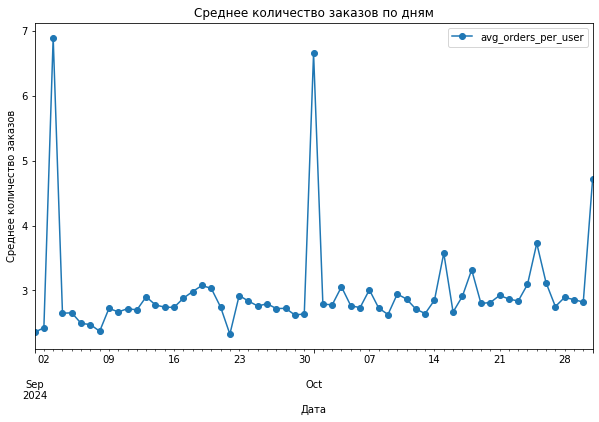

In [87]:
avg_orders_line = daily_stats.plot(kind='line',
                      x='created_dt_msk',
                      y='avg_orders_per_user',    
                      figsize=(10, 6),
                      marker='o',
                      title='Среднее количество заказов по дням')

avg_orders_line.set_xlabel('Дата')
avg_orders_line.set_ylabel('Среднее количество заказов')
plt.show()

Видим, что значения на графике варьируются от 1 до 7, при этом редко превышая отметку 3. Имеется несколько пиковых значений - 3 сентября, 1, 15, 18, 25 и 31 октября, что совпадает с предыдущими графиками и вновь свидетельствует о повышении спроса среди пользователей в эти даты.

Вычислим среднюю стоимость одного билета на основе столбца `one_ticket_revenue_rub` и визуализируем результаты.

In [88]:
avg_revenue_per_ticket = df_fall.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean()

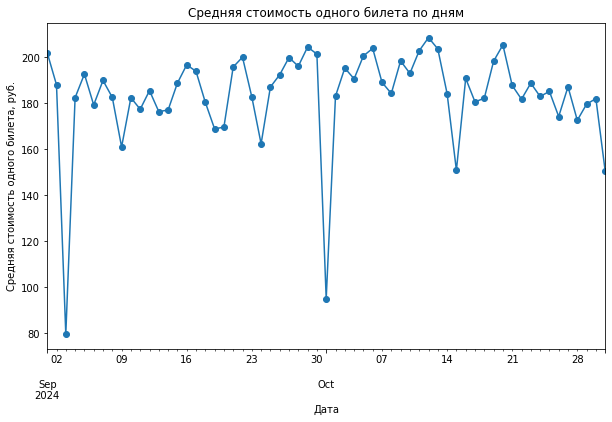

In [89]:
avg_revenue_per_ticket.plot(kind='line',
                            xlabel = 'Дата',
                            ylabel = 'Средняя стоимость одного билета, руб.',
                            figsize=(10, 6),
                            marker='o',
                            title='Средняя стоимость одного билета по дням')

plt.show()

В данном графике наблюдаем "зеркальную" картину - в обозначенные нами ранее даты фиксируется резкий спад средней стоимости одного билета. Например, 3 сентября средняя стоимость совершила экстремальный спад с 200 до 80 рублей. Аналогичная ситуация произошла 1, 15 и 31 октября, когда средняя стоимость обрушилась до низких значений.

Изучим недельную цикличность и сравним пользовательскую активность в будни и выходные.
Для этого сначала выделим из даты день недели.

In [90]:
daily_stats.loc[:,'day_of_week'] = daily_stats['created_dt_msk'].dt.dayofweek+1

Агрегируем данные по суткам (для каждой даты считаем количество заказов и уникальных пользователей).

In [91]:
daily_agg = (df.groupby('created_dt_msk').agg(dau=('user_id', 'nunique'), orders=('order_id', 'nunique')).reset_index())

Добавляем день недели уже к дневной агрегации.

In [92]:
daily_agg['day_of_week'] = daily_agg['created_dt_msk'].dt.dayofweek+1

Теперь посчитаем среднее по дням недели.

In [93]:
avg_by_weekday = (daily_agg.groupby('day_of_week').agg(avg_dau=('dau', 'mean'), avg_orders=('orders', 'mean')).round(2))

Построим график для наглядности.

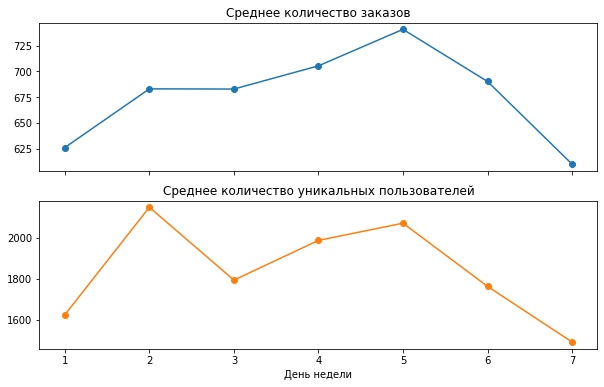

In [94]:
avg_by_weekday.plot(kind='line',
                 subplots=True,
                 sharex=True,
                 sharey=False,
                 legend=False,
                 figsize=(10, 6),
                 marker='o',
                 title=['Среднее количество заказов', 'Среднее количество уникальных пользователей'])

plt.xlabel('День недели')
plt.show()

Наибольшее количество заказов приходится на пятницу, при этом резко снижаясь к выходным. Начиная со вторника средний показатель вновь растет. 

Что касается уникальных пользователей, то здесь активность также приходится на будни, с наибольшими значением во вторник и четверг. После четверга динамика становится отрицательной и к воскресенью показатели падают практически до минимума. 

Таким образом, понедельник и выходные дни являются самыми "неактивными" по части оформления заказов. Делаем вывод, что пользователи склонны покупать билеты по будням - со вторника по пятницу.

<b>Промежуточный вывод</b>

В данном разделе мы проанализировали активность пользователей и среднюю стоимость одного билета в осенний период. 

Мы увидели, что пиковые значения по количеству заказов, количеству уникальных пользователей и среднему количеству заказов на одного пользователя совпадают вплоть до конкретных дат, что свидетельствует о повышении спроса среди пользователей именно в эти дни.
А вот в графике «Средняя стоимость одного билета» мы наблюдали «зеркальную» картину - резкий спад средней стоимости одного билета в те же даты.

Вероятнее всего, в обозначенные даты сервис/организаторы предлагали скидку или иное специальное предложение для пользователей, что послужило причиной повышенного спроса и оказало влияние на среднюю стоимость билета.

Мы выяснили, что пользователи склонны покупать билеты по будням - со вторника по пятницу. Данный тренд объясним, ведь большинство мероприятий проходит в выходные дни, что мотивирует пользователей покупать билеты за несколько дней до ивента.

Следует дополнительно проанализировать, какие события (маркетинговые активности и др.) происходят в наиболее активные дни и стимулируют людей покупать билеты. Возможно, акции и скидки выпадают как раз на эти дни недели. 


<b>Популярные события и партнёры</b>

Для каждого региона посчитаем уникальное количество мероприятий, общее число заказов и суммарную выручку. 

In [123]:
df_regions_agg = (df.groupby('region_name').agg(orders_count=('order_id', 'count'), events_count=('event_id', 'nunique'), total_revenue=('total', 'sum')).sort_values(by='total_revenue', ascending=False))
df_regions_agg

,orders_count,events_count,total_revenue
region_name,,,
Каменевский регион,88939,5891,6.282155e+08
Североярская область,43581,3793,2.702432e+08
Широковская область,16145,1232,9.820261e+07
Озернинский край,10231,349,9.656400e+07
Малиновоярский округ,6307,165,5.179619e+07
...,...,...,...
Крутоводский регион,18,7,6.236283e+04
Теплоозёрский округ,7,2,5.769993e+04
Яснопольский округ,21,5,3.216590e+04


Теперь для каждого региона посчитаем долю проводимых мероприятий от их общего числа. 

In [127]:
total_events = df['event_id'].nunique()
df_regions_agg['events_share'] = (df_regions_agg['events_count'] / total_events) * 100
df_regions_agg['events_share'].sort_values(ascending=False)

region_name
Каменевский регион          26.527671
Североярская область        17.080200
Широковская область          5.547800
Светополянский округ         4.800288
Речиновская область          3.129644
                              ...    
Лесноярский край             0.009006
Сосноводолинская область     0.009006
Теплоозёрский округ          0.009006
Верхозёрский край            0.009006
Шанырский регион             0.004503
Name: events_share, Length: 80, dtype: float64

Абсолютным лидером по количеству оформленных заказов, количеству мероприятий и суммарной выручке выступает Каменевский регион, на него приходится 26,5% от общего числа ивентов. В этом регионе было оформлено вдвое больше заказов, чем, например, в Североярской области (2-е место и 17%). На 3-м месте Широковская область с долей 5,5%. 

Визуализируем результаты для топ-7 регионов.

In [97]:
top_7_regions = df_regions_agg['events_share'].nlargest(7)

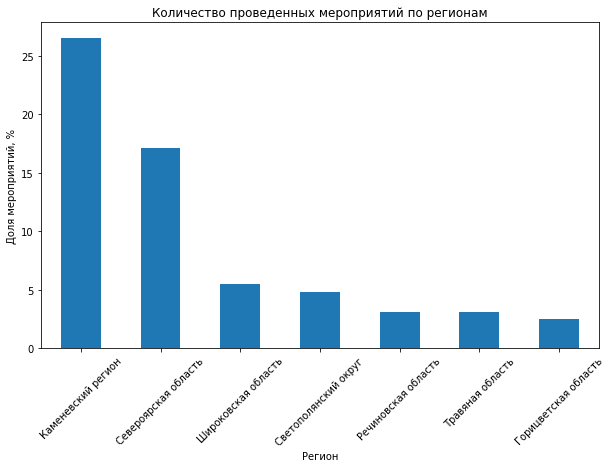

In [98]:
top_7_regions.plot(kind='bar', 
                   figsize=(10, 6),
                   xlabel = 'Регион',
                   ylabel = 'Доля мероприятий, %',
                   title='Количество проведенных мероприятий по регионам',
                   rot=45)
 
plt.show()

Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.

In [99]:
df_service_name_agg = (df.groupby('service_name').agg(orders_count=('order_id', 'count'), events_count=('event_id', 'nunique'), total_revenue=('revenue_rub', 'sum')).sort_values(by='orders_count', ascending=False))
df_service_name_agg

,orders_count,events_count,total_revenue
service_name,,,
Билеты без проблем,60884,4185,2.360762e+07
Лови билет!,40419,4853,1.651013e+07
Билеты в руки,40227,3523,1.316003e+07
Мой билет,31011,1279,1.770090e+07
Облачко,26295,2330,1.846356e+07
Лучшие билеты,17740,1762,2.721491e+06
Весь в билетах,16296,852,1.636691e+07
Прачечная,10204,1019,4.715755e+06
Край билетов,6065,249,6.352563e+06


Для каждого билетного партнера посчитаем долю принесенной выручки.

In [126]:
sum_revenue = df['revenue_rub'].sum()
df_service_name_agg['revenue_share'] = (df_service_name_agg['total_revenue'] / sum_revenue) * 100
df_service_name_agg['revenue_share'].sort_values(ascending=False)

service_name
Билеты без проблем        16.459075
Облачко                   12.872668
Мой билет                 12.340947
Лови билет!               11.510750
Весь в билетах            11.410900
Билеты в руки              9.175087
Край билетов               4.428964
Прачечная                  3.287792
Дом культуры               3.038825
Яблоко                     2.674837
Тебе билет!                2.017942
Лучшие билеты              1.897405
За билетом!                1.419416
Мир касс                   1.279403
Городской дом культуры     1.144316
Быстробилет                1.068691
Show_ticket                1.008817
Выступления.ру             0.849603
Восьмёрка                  0.458620
Росбилет                   0.358715
Шоу начинается!            0.323247
Crazy ticket!              0.315079
Быстрый кассир             0.276570
Телебилет                  0.130600
Дырокол                    0.072562
Радио ticket               0.057095
Билет по телефону          0.050510
Реестр         

Самым активным билетным партнером оказался сервис "Билеты без проблем", именно он внёс наибольший вклад в общую выручку (16,4%). Второе место и третье место занимают сервисы "Облачко" и "Мой билет", они принесли 12,3% и 12,8% выручки соответственно. Сервисы "Лови билет!" и "Весь в билетах" принесли примерно одинаковую выручку в общую кассу (11,4% и 11,5%).

Визуализируем результаты для топ-7 билетных партнеров.

In [101]:
top_7_services = df_service_name_agg['revenue_share'].nlargest(7)

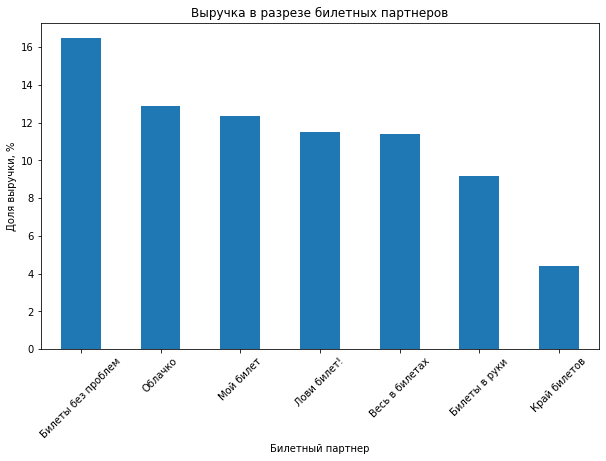

In [102]:
top_7_services.plot(kind='bar', 
                   figsize=(10, 6),
                   xlabel = 'Билетный партнер',
                   ylabel = 'Доля выручки, %',
                   title='Выручка в разрезе билетных партнеров',
                   rot=45)
 
plt.show()

 <b>Промежуточный вывод</b>

В данном разделе мы выделили ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.
Сервис представлен в 80 регионах, то есть покрывает практически всю страну. При этом в списке есть явные лидеры. Так, абсолютным рекордсменом по количеству оформленных заказов, количеству мероприятий и суммарной выручке выступает Каменевский регион, на него приходится 26,5% от общего числа ивентов. Отметим, что разрыв между 1-м и 2-м местом достаточно большой - 9.5%, а с третьим - 21%. Надо сказать, что количество заказов явно коррелирует с количеством мероприятий, проводимых в регионе. В целом же, рейтинг регионов не выглядит сбалансированным. 

Что касается билетных партнеров, то здесь рейтинг выглядит более сбалансированным. Большого разрыва между лидерами нет, первые пять строчек рейтинга имеют от 11% до 16% долей рынка, а значит признаков монополизации не наблюдается.
Однако примерно половина игроков рынка занимают менее 1%. Например, компании, через которые было продано всего несколько билетов. Руководству компании стоит обратить внимание на эти сервисы и подумать, какие драйверы роста существуют в партнерстве с ними, либо принять решение о прекращении сотрудничества за неимением перспектив.


# Статистический анализ данных

Коллеги из продуктового отдела хотят отдельно проверить несколько гипотез относительно активности пользователей мобильных и стационарных устройств. 

Проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств. Используем данные только за осенний период.

Перед проверкой гипотез изучим сравниваемые данные, а именно оценим количество пользователей в каждой группе и убедимся в отсутствии пересечений между группами.

Рассчитаем количество уникальных пользователей в каждой из наблюдаемых групп.

In [103]:
mob_group = df_fall[df_fall['device_type_canonical']=='mobile']['user_id'].nunique() 
desktop_group = df_fall[df_fall['device_type_canonical']=='desktop']['user_id'].nunique() 
print(f'Количество пользователей в первой группе:{mob_group}') 
print(f'Количество пользователей во второй группе:{desktop_group}') 

Количество пользователей в первой группе:13826
Количество пользователей во второй группе:4767


Видим, что распределение пользователей в группах неравномерное и наблюдается явный перекос в сторону первой группы. 

Узнаем, нет ли пересечений в группах, и убедимся, что никто из пользователей случайно не попал в обе группы одновременно.

In [104]:
mob_group_int = df_fall[df_fall['device_type_canonical']=='mobile']['user_id']
desktop_group_int = df_fall[df_fall['device_type_canonical']=='desktop']['user_id']
intersection = list(set(mob_group_int) & set(desktop_group_int))
print(len(intersection))

3181


Видим, что 3181 пользователь попал в обе группы. Значит, группы перестают быть независимыми, что для проведения статистического теста критично.

Таким образом, выявлено две проблемы:

1. Сильный перекос количества пользователей в пользу первой группы
2. Крупное пересечение между группами

Полностью удалить пересекающихся пользователей мы не можем, т.к. это будет означать избавление от большой части данных. Попробуем присвоить всем пользователям признак "доминирующий тип устройства" и оставить пользователя в той группе, в которой он совершил 60% заказов. Например, если 4 заказа из 6 пользователь совершил через мобильное устройство, оставляем его в первой группе, и наоборот.

In [105]:
# Считаем число заказов по пользователям и устройствам
user_dev_orders = (
    df_fall
    .groupby(['user_id', 'device_type_canonical'])['order_id']
    .nunique()
    .reset_index(name='orders_count')
)

In [106]:
# Считаем общее число заказов по пользователю
user_total = (
    user_dev_orders
    .groupby('user_id')['orders_count']
    .sum()
    .rename('total_orders')
    .reset_index()
)

In [107]:
# Объединяем и считаем долю
user_dev = user_dev_orders.merge(user_total, on='user_id')
user_dev['share'] = user_dev['orders_count'] / user_dev['total_orders']

In [108]:
# Для каждого пользователя выбираем устройство с максимальной долей и удаляем "дубль"

user_main = (
    user_dev
    .sort_values(['user_id', 'share'], ascending=[True, False])
    .drop_duplicates(subset='user_id', keep='first')
    [['user_id', 'device_type_canonical', 'share']]
    .rename(columns={'device_type_canonical': 'main_device', 'share': 'main_device_share'})
)

In [109]:
# Создаем функцию, чтобы присвоить признак "доминирующий тип"

def get_main_device(row, threshold=0.6):
    if row['main_device_share'] >= threshold:
        return row['main_device']
    else:
        return 'other'
    
user_main['main_device'] = user_main.apply(
    get_main_device,
    axis=1,
    threshold=0.6
)

In [110]:
# Добавляем признак ко всем строкам 
df_with_main = df.merge(user_main[['user_id', 'main_device']], on='user_id', how='left')

Проверим, как распределились данные между группами.

In [111]:
print("Распределение доминирующих устройств:")
print(df_with_main['main_device'].value_counts())

Распределение доминирующих устройств:
mobile     246041
other       12906
desktop     11212
Name: main_device, dtype: int64


Посмотрим на распределение числа заказов среди мобильных пользователей и пользователей стационарной версии.

Для этого построим гистограммы и диаграммы размаха.

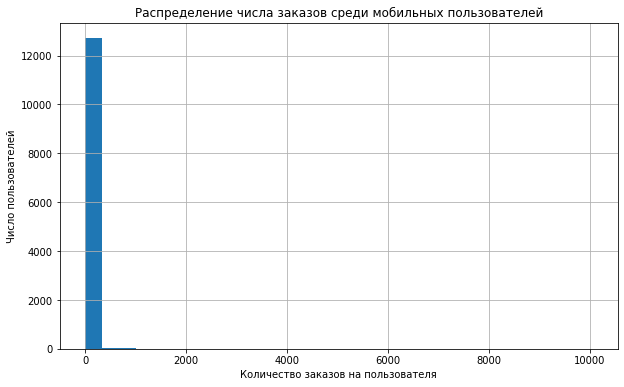

In [112]:
mob_group_1 = df_with_main[df_with_main['main_device']=='mobile'].groupby('user_id')['order_id'].nunique()
plt.figure(figsize=(10, 6))
mob_group_1.hist(bins=30)
plt.title('Распределение числа заказов среди мобильных пользователей')
plt.xlabel('Количество заказов на пользователя')
plt.ylabel('Число пользователей')
plt.show()

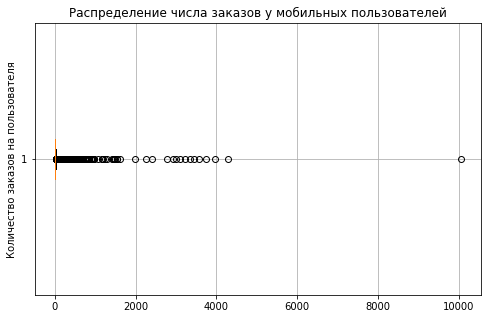

In [113]:
plt.figure(figsize=(8, 5))
plt.boxplot(mob_group_1, vert=False)

plt.title('Распределение числа заказов у мобильных пользователей')
plt.ylabel('Количество заказов на пользователя')
plt.grid()
plt.show()

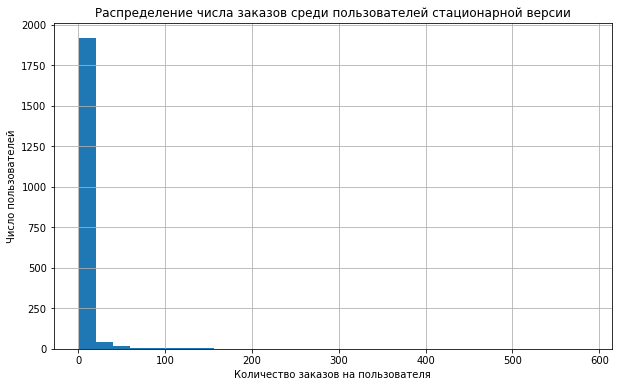

In [114]:
desktop_group_1 = df_with_main[df_with_main['main_device']=='desktop'].groupby('user_id')['order_id'].nunique()
plt.figure(figsize=(10, 6))
desktop_group_1.hist(bins=30)
plt.title('Распределение числа заказов среди пользователей стационарной версии')
plt.xlabel('Количество заказов на пользователя')
plt.ylabel('Число пользователей')
plt.show()

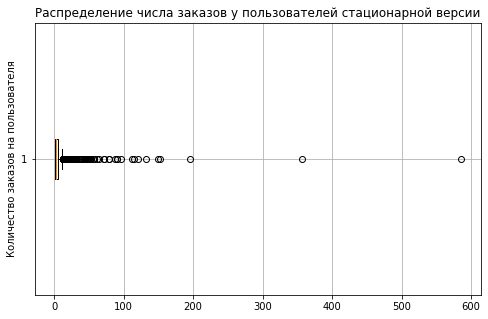

In [115]:
plt.figure(figsize=(8, 5))
plt.boxplot(desktop_group_1, vert=False)

plt.title('Распределение числа заказов у пользователей стационарной версии')
plt.ylabel('Количество заказов на пользователя')
plt.grid()
plt.show()

Обе гистограммы имеют ассиметричную форму, а именно "правые хвосты". Также видим, что данные не распределены нормально, так как содержат аномальные значения (выбросы). 
Для проверки обеих гипотез выберем статистический тест Манна — Уитни. Выбор теста обусловлен сразу несколькими причинами:
- перекос количества пользователей в пользу первой выборки;
- наличие выбросов в обеих группах.

В отличие от t-теста Стьюдента тест Манна — Уитни не использует абсолютные значения, а основывается на принципе присваивания рангов и позволяет определить, в какой группе распределение смещено в сторону больших значений.

Приступим к проверке первой гипотезы. 

Первая гипотеза звучит так: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза H₀: Среднее количество заказов на одного пользователя через мобильное приложения меньше или равно среднему количеству заказов на одного пользователя стационарной версии.

Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя через мобильное приложения больше, и это различие статистически значимо.

In [116]:
# Данные по мобильной версии
mob_group_1 = df_with_main[df_with_main['main_device']=='mobile'].groupby('user_id')['order_id'].nunique()

# Данные по десктопной версии
desktop_group_1 = df_with_main[df_with_main['main_device']=='desktop'].groupby('user_id')['order_id'].nunique()

# Уровень статистической значимости
alpha = 0.05 

results = mannwhitneyu(
    mob_group_1, 
    desktop_group_1,
    alternative='greater' 
)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-значение: 6.296581142542527e-26
Отвергаем нулевую гипотезу


Уровень статистической значимости - 0.05.

По результатам теста p-value равно 6.296581142542527e-26. 

Интерпретируем результат: p-value меньше уровня значимости, из чего следует, что нулевая гипотеза НЕ подтверждается.

<b>Проверяем вторую гипотезу.</b>

Вторая гипотеза звучит так: среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств

Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза H₀: Среднее время между заказами пользователей через мобильное приложения меньше или равно среднему времени между заказами пользователей стационарной версии.

Альтернативная гипотеза H₁: Среднее время между заказами пользователей через мобильное приложения больше, и это различие статистически значимо.

В данном случае следует учитывать СТРОГО тех пользователей, совершавших заказы только на одном устройстве, чтобы избежать перемешивания заказов (например, заказ с мобильного был между двумя заказами со стационарного устройства). Для этого избавимся от пересечений.

In [117]:
filtered_df_fall = df_fall[~df_fall['user_id'].isin(intersection)]

Перед проведением теста вычислим количество дней между заказами и оставим только пользователей, совершивших 2 и более заказов.

In [118]:
# Считаем заказы у каждого пользователя
orders_count = filtered_df_fall.groupby('user_id')['order_id'].nunique()

# Оставляем только тех, у кого 2 и больше заказов 
users_with_multi_orders = orders_count[orders_count >= 2].index

# Оставляем только строки этих пользователей
filtered_df_fall = filtered_df_fall[filtered_df_fall['user_id'].isin(users_with_multi_orders)].copy()

In [119]:
# Сортируем данные и находим разницу между датами заказа
df_test = filtered_df_fall.sort_values(['user_id', 'created_dt_msk'], kind='mergesort')
df_test['time_diff'] = df_test.groupby('user_id')['created_dt_msk'].diff()

# Переводим полученные числа в дни
df_test['days_between'] = df_test['time_diff'].dt.days

In [120]:
# Данные по мобильной версии + избавляемся от пропусков
mob_group_2 = df_test[df_test['device_type_canonical']=='mobile']['days_between'].dropna()

# Данные по десктопной версии + избавляемся от пропусков
desktop_group_2 = df_test[df_test['device_type_canonical']=='desktop']['days_between'].dropna()

# Уровень статистической значимости
alpha = 0.05 

results = mannwhitneyu(
    mob_group_2, 
    desktop_group_2,
    alternative='greater' 
)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-значение: 3.873729735416264e-80
Отвергаем нулевую гипотезу


Уровень статистической значимости - 0.05.

По результатам теста p-value равно 3.873729735416264e-80. 

Интерпретируем результат: p-value меньше уровня значимости, из чего следует, что нулевая гипотеза НЕ подтверждается.

<b>Общий вывод и рекомендации</b>

В ходе исследования проанализировали данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Данные включали информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных, информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Дополнительно нам была предоставлена информация о курсе тенге к российскому рублю за 2024 год, поскольку в исходном датасете данные были представлены в двух валютах – российских рублях и тенге.

Акцент исследования был сделан на факторе сезонности, а именно на том, как изменилось поведение и активность пользователей с наступлением осени. Для осеннего и летнего периодов мы сравнили распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. Изучили изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.

Отдельно мы оценили активность пользователей осенью 2024 года и разработали рейтинги регионов и билетных сервисов.
Исследовательский анализ данных позволил сформулировать выводы относительно влияния фактора сезонности.

<b>Сравнение активности пользователей летом и осенью:</b>

•	Осенью пользователи стали чаще покупать билеты на три типа мероприятий: "спорт", "театр" и "ёлки". Причины: спортивный и театральный сезоны обычно начинаются в конце лета или начале осени, совпадая с началом учебного года и возвращением людей из отпусков. Приближение новогодних ивентов объясняет повышение интереса к типу мероприятия "ёлки". 

•	В осенний сезон пользователи по-прежнему предпочитают мобильную версию. Однако стационарная платформа прибавила почти 2% по сравнению с летом. 

•	С наступлением осени у пользователей возрос интерес к мероприятиям категории "0" и "12". Скорее всего это мероприятия, ориентированные на детей и подростков. 

•	Вопреки ожиданиям, осенью средняя выручка с одного билета выросла только в трех типах мероприятий. По остальным категориям мероприятий средняя выручка с одного билета показывает отрицательную динамику. Стоит присмотреться к этим категориям и выяснить причины столь значительного падения средней выручки при абсолютном росте количества заказов. 

<b>Исследование активности в осенний период:</b>

•	Пиковые значения по количеству заказов, количеству уникальных пользователей и среднему количеству заказов на одного пользователя совпадают вплоть до конкретных дат, что свидетельствует о повышении спроса среди пользователей именно в эти дни.

•	По метрике «Средняя стоимость одного билета» наблюдается «зеркальная» картина - резкий спад значений в те же даты. Вероятнее всего, в обозначенные даты сервис/организаторы предлагали скидку или иное специальное предложение для пользователей, что послужило причиной повышенного спроса и оказало влияние на среднюю стоимость билета.

•	Пользователи склонны покупать билеты по будням - со вторника по пятницу. Следует дополнительно проанализировать, какие события (маркетинговые активности и др.) происходят в наиболее активные дни и стимулируют людей покупать билеты. Возможно, акции и скидки выпадают как раз на эти дни недели. 

<b>Рейтинг регионов и билетных партнеров</b>

•	Сервис представлен в 80 регионах, то есть покрывает практически всю страну. Абсолютным рекордсменом по количеству оформленных заказов, количеству мероприятий и суммарной выручке выступает Каменевский регион, на него приходится 26,5% от общего числа ивентов. При этом разрыв между 1-м и 2-м местом достаточно большой - 9.5%, а с третьим - 21%. Количество заказов явно коррелирует с количеством мероприятий, проводимых в регионе. Отметим, что рейтинг регионов не выглядит сбалансированным. 

•	Рейтинг билетных партнеров выглядит более сбалансированным. Большого разрыва между лидерами нет, первые пять строчек рейтинга имеют от 11% до 16% долей рынка, а значит признаков монополизации не наблюдается. Примерно половина игроков рынка занимают менее 1%. Руководству компании стоит обратить внимание на эти сервисы и подумать, какие драйверы роста существуют в партнерстве с ними, либо принять решение о прекращении сотрудничества за неимением перспектив.

<b>Проверка гипотез</b>

По просьбе коллег из продуктового отдела были проверены две гипотезы относительно активности пользователей мобильных и стационарных устройств. Обе гипотезы предполагали большую активность пользователей мобильных устройств.
Нам предстояло определить, существует ли значимая статистическая разница между двумя средними. Для проверки обеих гипотез был выбран статистический тест Манна — Уитни. 
В обоих случаях нулевая гипотеза - об отсутствии статистической разницы между активностью пользователей мобильных и стационарных устройств - не нашла подтверждения. Таким образом, мы попали в зону принятия альтернативных гипотез, а именно:

•	Среднее количество заказов на одного пользователя мобильного приложения <b>ВЫШЕ</b> по сравнению с пользователями стационарных устройств.

•	Среднее время между заказами пользователей мобильных приложений <b>ВЫШЕ</b> по сравнению с пользователями стационарных устройств.

Мы доказали, что активность пользователей мобильных устройств действительно больше, а значит имеет смысл делать акцент на дополнительное продвижение именно этой платформы.

<b>Рекомендации</b>
    
В качестве рекомендаций стоит обратить внимание на удержание пользователей в летний период, чтобы поддерживать их вовлеченность, а осенью направить усилие на те сегменты, которые не показывают положительную динамику. 
    
Для билетных партнеров, которые пока не приносят большую выручку, можно предложить дополнительные стимулирующие программы, более выгодные условия партнерства либо подумать о прекращении сотрудничества.
    
Дополнительно можно провести более детальную сегментацию, чтобы выделить когорты наиболее активных клиентов, либо билетных партнеров.
